# District Malnutrition EDA

This notebook reads the cleaned SQLite database created by `build_database.py` and performs early exploratory data analysis for the DSM project.

Scope of this notebook:
- inspect the cleaned merged dataset
- review merge coverage and missingness
- summarize key child nutrition indicators
- compare NFHS-4 and NFHS-5 outcomes where overlap exists
- explore early relationships across agriculture, water/sanitation, and healthcare variables


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
db_candidates = [
    Path('data/district_malnutrition_eda.db'),
    Path('district_malnutrition_eda/data/district_malnutrition_eda.db'),
    Path('/content/district_malnutrition_eda/data/district_malnutrition_eda.db'),
]

DB_PATH = next((path for path in db_candidates if path.exists()), None)
if DB_PATH is None:
    raise FileNotFoundError('Could not find district_malnutrition_eda.db. Run build_database.py first.')

WORKSPACE_DIR = DB_PATH.parent.parent
OUTPUT_DIR = WORKSPACE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH


WindowsPath('data/district_malnutrition_eda.db')

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    table_names = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY name",
        conn,
    )
    analysis = pd.read_sql_query('SELECT * FROM analysis_district', conn)
    merge_summary = pd.read_sql_query('SELECT * FROM merge_summary', conn)
    nutrition_change = pd.read_sql_query('SELECT * FROM nutrition_change_4_to_5', conn)
    merge_unmatched = pd.read_sql_query('SELECT * FROM merge_unmatched', conn)

print('Tables in database:')
display(table_names)
print('\nMerge summary:')
display(merge_summary)
print('\nAnalysis shape:', analysis.shape)


Tables in database:


,name
0,agriculture_2019
1,analysis_district
2,districts
3,hmis_2019
4,jjm_2025
5,merge_summary
6,merge_unmatched
7,nfhs4_total
8,nfhs5
9,nutrition_change_4_to_5



Merge summary:


,source_name,rows_total,rows_matched,rows_unmatched,unique_district_keys,matched_unique_districts
0,nfhs4_total,637,635,2,637,635
1,nfhs5,704,704,0,704,704
2,agriculture_2019,10797,10565,232,391,376
3,hmis_2019,704,698,6,704,698
4,jjm_2025,753,687,66,753,687



Analysis shape: (704, 29)


In [4]:
analysis.head()


,district_id,state_name,district_name,state_key,district_key,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct,improved_water_pct,improved_sanitation_pct,clean_fuel_pct,women_10plus_schooling_pct,women_literacy_pct,institutional_births_pct,crop_count,total_area_ha,total_production_t,weighted_yield_t_per_ha,institutional_deliveries_pct,anc_4plus_pct,immunisation_sessions_pct,hjg_villages_reported_ratio,hjg_villages_certified_ratio,stunting_pct_nfhs4,wasting_pct_nfhs4,underweight_pct_nfhs4,anaemia_children_u5_pct_nfhs4,usable_for_eda
0,1,Andaman And Nicobar Islands,Nicobars,andaman and nicobar islands,nicobars,21.60,15.70,24.60,37.70,98.80,83.50,56.90,53.50,87.50,97.80,13.00,"17,395.32","89,061,461.50","5,119.85",95.80,59.00,85.40,1.00,1.00,20.30,7.40,10.50,50.50,1
1,2,Andaman And Nicobar Islands,North And Middle Andaman,andaman and nicobar islands,north and middle andaman,27.00,27.00,42.80,30.40,92.20,86.40,61.30,41.00,84.00,97.70,18.00,"11,124.14","7,640,988.43",686.88,93.30,60.50,97.60,1.00,1.00,32.50,31.70,33.50,47.30,1
2,3,Andaman And Nicobar Islands,South Andamans,andaman and nicobar islands,south andamans,21.10,12.60,17.40,43.40,97.90,89.30,91.90,57.50,86.70,99.50,16.00,"4,926.65","15,897,030.75","3,226.74",99.30,71.10,96.80,1.00,1.00,20.10,15.60,18.50,49.60,1
3,4,Andhra Pradesh,Ananthapuramu,andhra pradesh,ananthapuramu,36.00,19.30,40.60,55.80,98.80,71.30,86.40,31.30,63.60,94.70,35.00,"1,229,622.00","8,664,795.00",7.05,99.80,95.90,98.70,0.21,0.11,40.30,15.20,39.30,53.00,1
4,5,Andhra Pradesh,Chittoor,andhra pradesh,chittoor,27.10,14.80,27.90,54.90,98.50,74.60,86.60,40.30,69.30,97.10,32.00,"367,350.00","23,830,483.00",64.87,100.00,90.20,99.90,1.00,0.99,31.40,18.10,32.40,46.60,1


,column,missing_count,missing_pct
9,weighted_yield_t_per_ha,328,46.59
10,hjg_villages_reported_ratio,17,2.41
7,institutional_deliveries_pct,6,0.85
8,anc_4plus_pct,6,0.85
2,underweight_pct,0,0.00
0,stunting_pct,0,0.00
1,wasting_pct,0,0.00
6,women_10plus_schooling_pct,0,0.00
5,improved_sanitation_pct,0,0.00
4,improved_water_pct,0,0.00


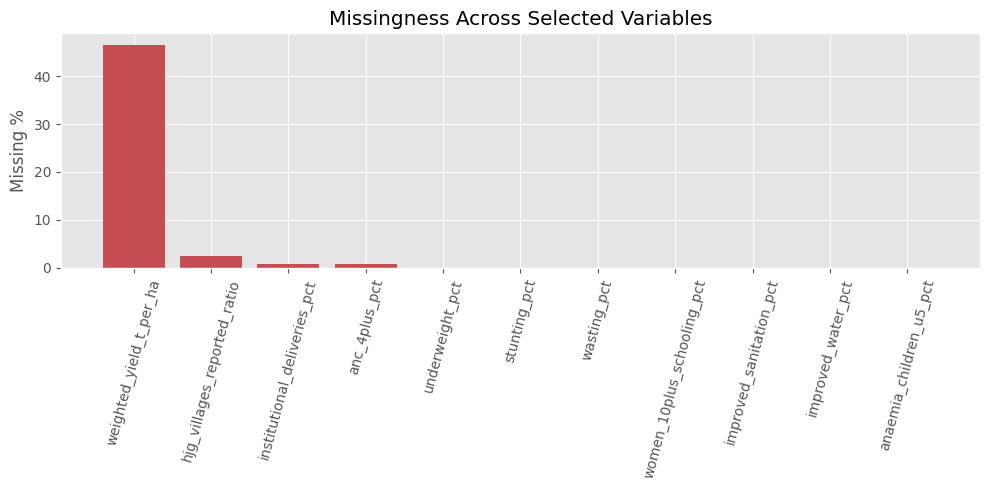

In [5]:
selected_columns = [
    'stunting_pct',
    'wasting_pct',
    'underweight_pct',
    'anaemia_children_u5_pct',
    'improved_water_pct',
    'improved_sanitation_pct',
    'women_10plus_schooling_pct',
    'institutional_deliveries_pct',
    'anc_4plus_pct',
    'weighted_yield_t_per_ha',
    'hjg_villages_reported_ratio',
]

missingness = pd.DataFrame({
    'column': selected_columns,
    'missing_count': [analysis[col].isna().sum() for col in selected_columns],
})
missingness['missing_pct'] = 100 * missingness['missing_count'] / len(analysis)
missingness = missingness.sort_values('missing_pct', ascending=False)
display(missingness)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missingness['column'], missingness['missing_pct'], color='#C44E52')
ax.set_title('Missingness Across Selected Variables')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


In [6]:
descriptive_columns = [
    'stunting_pct',
    'wasting_pct',
    'underweight_pct',
    'anaemia_children_u5_pct',
    'improved_water_pct',
    'improved_sanitation_pct',
    'women_10plus_schooling_pct',
    'institutional_deliveries_pct',
    'anc_4plus_pct',
    'weighted_yield_t_per_ha',
]

desc = analysis[descriptive_columns].describe().T
display(desc)
desc.to_csv(OUTPUT_DIR / 'descriptive_statistics.csv')
missingness.to_csv(OUTPUT_DIR / 'missingness_summary.csv', index=False)


,count,mean,std,min,25%,50%,75%,max
stunting_pct,704.00,33.52,8.48,13.20,27.30,32.80,39.30,60.60
wasting_pct,704.00,18.60,6.52,4.50,13.90,18.10,22.80,48.00
underweight_pct,704.00,29.56,9.72,7.20,22.10,29.50,36.30,62.40
anaemia_children_u5_pct,704.00,65.90,12.04,24.90,59.60,67.70,74.03,95.50
improved_water_pct,704.00,93.75,8.68,41.20,92.00,97.00,99.30,100.00
improved_sanitation_pct,704.00,71.89,14.27,29.20,61.98,73.70,83.30,99.90
women_10plus_schooling_pct,704.00,40.24,14.15,13.60,29.23,39.00,49.73,88.20
institutional_deliveries_pct,698.00,93.63,10.61,27.90,92.40,98.40,99.80,100.00
anc_4plus_pct,698.00,78.64,23.01,4.90,68.12,81.35,91.38,276.50
weighted_yield_t_per_ha,376.00,367.62,"1,101.78",0.48,2.29,4.24,44.38,"10,234.28"


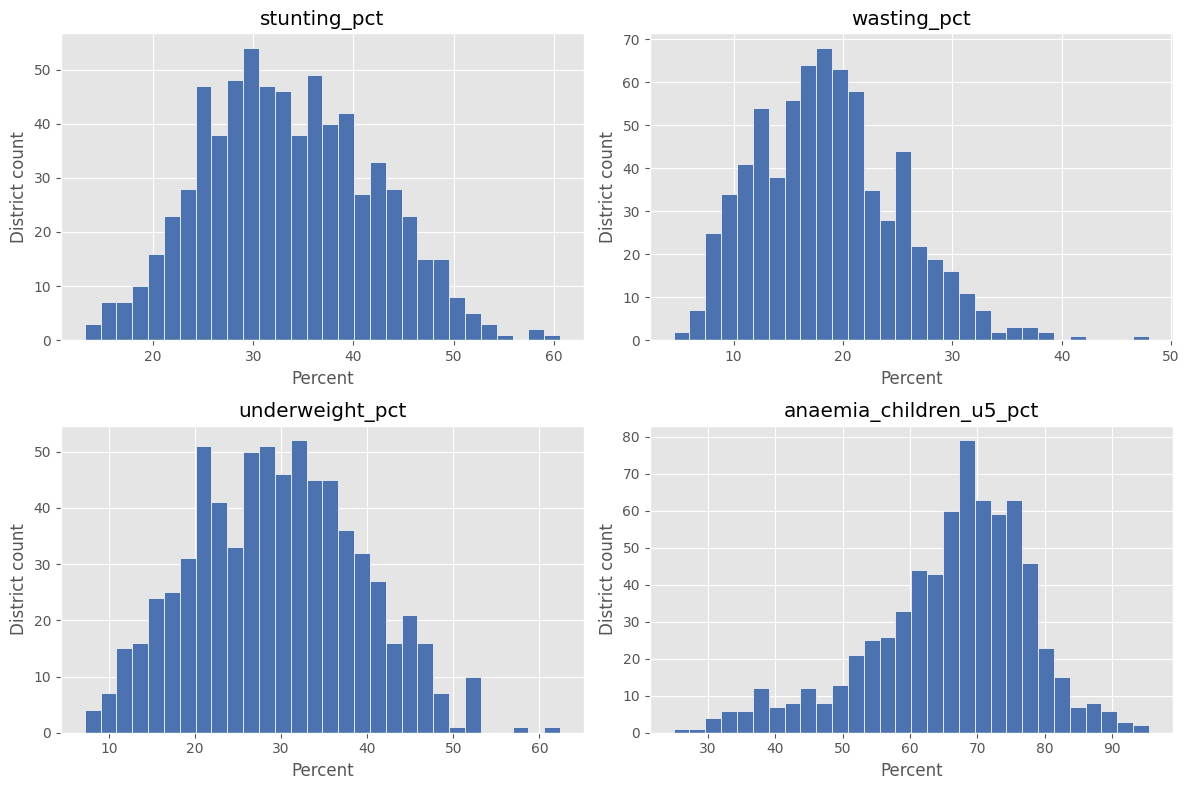

In [7]:
nutrition_cols = [
    'stunting_pct',
    'wasting_pct',
    'underweight_pct',
    'anaemia_children_u5_pct',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), nutrition_cols):
    ax.hist(analysis[col].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Percent')
    ax.set_ylabel('District count')
plt.tight_layout()
plt.show()


,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct,mean_nutrition_burden
state_name,,,,,
Gujarat,38.66,26.14,40.33,79.84,46.24
Bihar,42.59,24.25,41.73,70.08,44.66
Jharkhand,40.19,23.11,40.40,68.22,42.98
Maharashtra,35.05,26.01,36.77,70.47,42.08
The Dadra And Nagar Haveli And Daman And Diu,35.43,21.17,33.30,73.37,40.82
Ladakh,30.40,17.45,20.40,91.70,39.99
Madhya Pradesh,35.35,19.31,33.16,72.06,39.97
Telangana,33.16,22.44,32.89,70.13,39.65
Assam,35.70,20.69,31.61,69.82,39.45


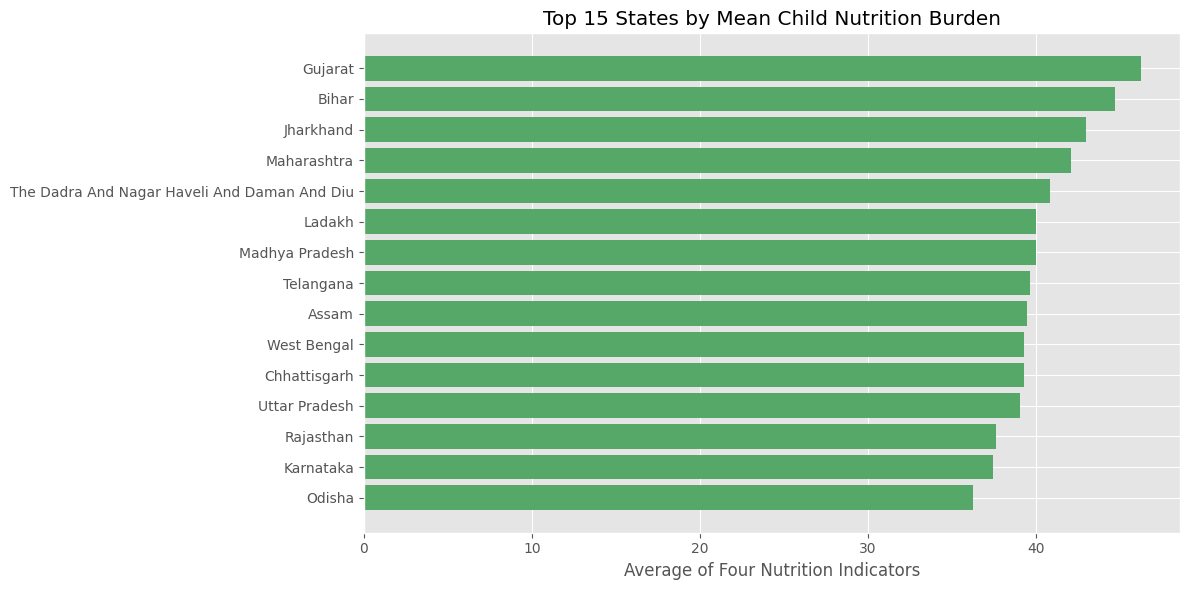

In [8]:
state_summary = (
    analysis.groupby('state_name')[nutrition_cols]
    .mean()
    .assign(mean_nutrition_burden=lambda df: df.mean(axis=1))
    .sort_values('mean_nutrition_burden', ascending=False)
)

display(state_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 6))
top_states = state_summary.head(15).sort_values('mean_nutrition_burden')
ax.barh(top_states.index, top_states['mean_nutrition_burden'], color='#55A868')
ax.set_title('Top 15 States by Mean Child Nutrition Burden')
ax.set_xlabel('Average of Four Nutrition Indicators')
plt.tight_layout()
plt.show()


In [9]:
trend_columns = [
    'stunting_change_4_to_5',
    'wasting_change_4_to_5',
    'underweight_change_4_to_5',
    'anaemia_change_4_to_5',
]

nutrition_change[trend_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
stunting_change_4_to_5,635.00,-2.58,7.20,-27.70,-7.55,-3.10,2.55,16.90
wasting_change_4_to_5,635.00,-2.18,8.19,-34.10,-7.50,-2.00,3.15,30.40
underweight_change_4_to_5,635.00,-3.26,7.83,-27.50,-8.40,-2.90,1.60,30.80
anaemia_change_4_to_5,635.00,9.35,14.81,-47.40,-1.65,7.80,19.40,50.80


,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct,improved_water_pct,improved_sanitation_pct,women_10plus_schooling_pct,institutional_deliveries_pct,anc_4plus_pct,weighted_yield_t_per_ha
stunting_pct,1.00,0.24,0.70,0.33,-0.20,-0.48,-0.54,-0.18,-0.06,-0.24
wasting_pct,0.24,1.00,0.72,0.32,-0.19,-0.39,-0.37,0.16,0.16,-0.18
underweight_pct,0.70,0.72,1.00,0.44,-0.15,-0.61,-0.53,0.15,0.18,-0.21
anaemia_children_u5_pct,0.33,0.32,0.44,1.00,0.18,-0.49,-0.45,0.34,0.10,-0.43
improved_water_pct,-0.20,-0.19,-0.15,0.18,1.00,0.13,0.28,0.48,0.15,0.10
improved_sanitation_pct,-0.48,-0.39,-0.61,-0.49,0.13,1.00,0.58,-0.17,-0.06,0.31
women_10plus_schooling_pct,-0.54,-0.37,-0.53,-0.45,0.28,0.58,1.00,0.22,0.25,0.48
institutional_deliveries_pct,-0.18,0.16,0.15,0.34,0.48,-0.17,0.22,1.00,0.45,0.14
anc_4plus_pct,-0.06,0.16,0.18,0.10,0.15,-0.06,0.25,0.45,1.00,0.19
weighted_yield_t_per_ha,-0.24,-0.18,-0.21,-0.43,0.10,0.31,0.48,0.14,0.19,1.00


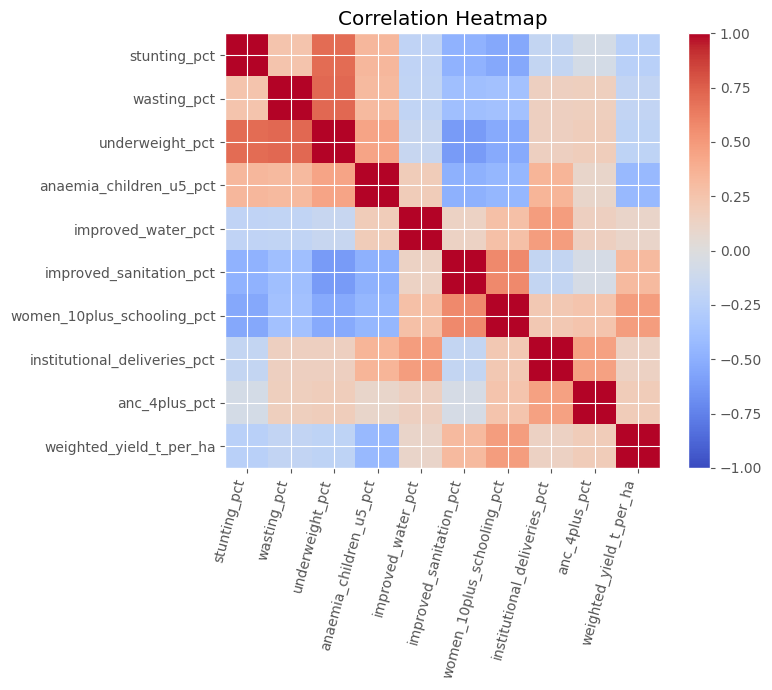

In [10]:
corr_columns = [
    'stunting_pct',
    'wasting_pct',
    'underweight_pct',
    'anaemia_children_u5_pct',
    'improved_water_pct',
    'improved_sanitation_pct',
    'women_10plus_schooling_pct',
    'institutional_deliveries_pct',
    'anc_4plus_pct',
    'weighted_yield_t_per_ha',
]

corr_df = analysis[corr_columns].dropna()
corr_matrix = corr_df.corr(numeric_only=True)
display(corr_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=75, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Correlation Heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


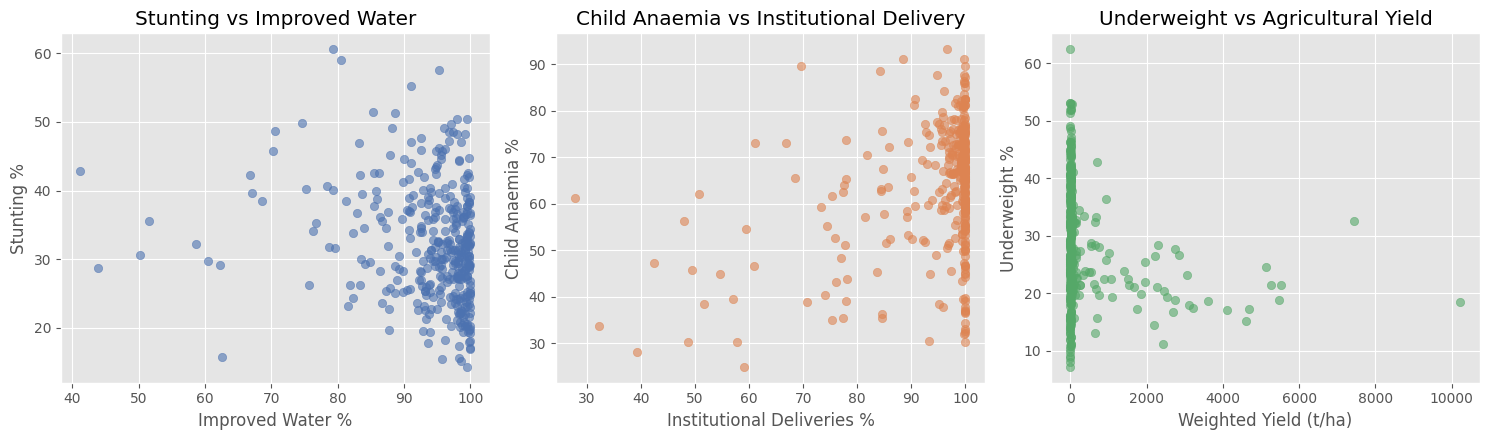

In [11]:
plot_df = analysis[
    [
        'stunting_pct',
        'underweight_pct',
        'anaemia_children_u5_pct',
        'improved_water_pct',
        'institutional_deliveries_pct',
        'weighted_yield_t_per_ha',
    ]
].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(plot_df['improved_water_pct'], plot_df['stunting_pct'], alpha=0.6, color='#4C72B0')
axes[0].set_title('Stunting vs Improved Water')
axes[0].set_xlabel('Improved Water %')
axes[0].set_ylabel('Stunting %')

axes[1].scatter(plot_df['institutional_deliveries_pct'], plot_df['anaemia_children_u5_pct'], alpha=0.6, color='#DD8452')
axes[1].set_title('Child Anaemia vs Institutional Delivery')
axes[1].set_xlabel('Institutional Deliveries %')
axes[1].set_ylabel('Child Anaemia %')

axes[2].scatter(plot_df['weighted_yield_t_per_ha'], plot_df['underweight_pct'], alpha=0.6, color='#55A868')
axes[2].set_title('Underweight vs Agricultural Yield')
axes[2].set_xlabel('Weighted Yield (t/ha)')
axes[2].set_ylabel('Underweight %')

plt.tight_layout()
plt.show()


In [12]:
merge_unmatched.sort_values(['source_name', 'state_name', 'district_name']).head(30)


,state_name,district_name,state_key,district_key,source_name
2,Arunachal Pradesh,Kamle,arunachal pradesh,kamle,agriculture_2019
3,Arunachal Pradesh,Leparada,arunachal pradesh,leparada,agriculture_2019
4,Arunachal Pradesh,Lower Siang,arunachal pradesh,lower siang,agriculture_2019
5,Arunachal Pradesh,Pakke Kessang,arunachal pradesh,pakke kessang,agriculture_2019
6,Arunachal Pradesh,Shi Yomi,arunachal pradesh,shi yomi,agriculture_2019
7,Chandigarh,Chandigarh,chandigarh,chandigarh,agriculture_2019
8,Tamil Nadu,Chengalpattu,tamil nadu,chengalpattu,agriculture_2019
9,Tamil Nadu,Kallakurichi,tamil nadu,kallakurichi,agriculture_2019
10,Tamil Nadu,Ranipet,tamil nadu,ranipet,agriculture_2019
11,Tamil Nadu,Tenkasi,tamil nadu,tenkasi,agriculture_2019
